# 1. Import the library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats

In [ ]:
# 1.1 setup visualization
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("All the settings are predefined ! ")

All the settings are predefined ! 


In [3]:
# 1.2 Load Data
base_dir = Path.cwd().parent
data_path_train = base_dir / "data" / "raw" / "olist_brazil_ml.csv"
train_data = pd.read_csv(data_path_train)
print(f"Training set: {train_data.shape[0]: ,} rows x {train_data.shape[1]} columns")

Training set:  95,343 rows x 27 columns


# 2. Data Inspection and Statics

## 2.1 Data Overview & Schema Inspection

In [4]:
train_df = train_data.copy()
train_df.head()

,review_score,is_satisfied,delivery_delay_days,estimated_delivery_days,actual_delivery_days,carrier_to_customer_days,review_answer_delay_days,total_order_value,total_freight_value,total_items,...,customer_lng,seller_state,seller_lat,seller_lng,seller_total_orders,seller_late_rate,seller_avg_review_score,seller_avg_delay,month,day_name
0,4,0,-15,22,7.0,5.0,1,34.59,12.69,1,...,-47.9248,SP,-21.1901,-47.7879,23,0.0000,4.174,-13.52,5,Monday
1,5,0,-8,21,13.0,6.0,3,126.54,26.74,2,...,-46.9014,SP,-20.8067,-49.3892,1391,0.0757,3.994,-10.94,2,Tuesday
2,5,0,-6,14,8.0,7.0,0,127.55,27.65,1,...,-45.9487,PR,-24.9447,-53.4903,94,0.0099,4.317,-17.20,8,Tuesday
3,5,0,-13,20,7.0,4.0,0,112.71,13.71,1,...,-46.8968,SP,-21.1127,-47.7908,376,0.0845,4.169,-11.65,8,Saturday
4,5,0,-7,9,2.0,1.0,0,35.84,7.94,1,...,-46.5552,SP,-23.1147,-46.5529,396,0.0794,4.072,-9.65,6,Monday


In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95343 entries, 0 to 95342
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   review_score              95343 non-null  int64  
 1   is_satisfied              95343 non-null  int64  
 2   delivery_delay_days       95343 non-null  int64  
 3   estimated_delivery_days   95343 non-null  int64  
 4   actual_delivery_days      95335 non-null  float64
 5   carrier_to_customer_days  95334 non-null  float64
 6   review_answer_delay_days  95343 non-null  int64  
 7   total_order_value         95340 non-null  float64
 8   total_freight_value       95343 non-null  float64
 9   total_items               95343 non-null  int64  
 10  freight_ratio             95340 non-null  float64
 11  payment_installments      95340 non-null  float64
 12  payment_value             95340 non-null  float64
 13  payment_type              95343 non-null  str    
 14  category_name_eng

In [6]:
train_df.describe()

,review_score,is_satisfied,delivery_delay_days,estimated_delivery_days,actual_delivery_days,carrier_to_customer_days,review_answer_delay_days,total_order_value,total_freight_value,total_items,...,payment_value,customer_lat,customer_lng,seller_lat,seller_lng,seller_total_orders,seller_late_rate,seller_avg_review_score,seller_avg_delay,month
count,95343.000000,95343.000000,95343.000000,95343.000000,95335.000000,95334.000000,95343.000000,95340.000000,95343.000000,95343.000000,...,95340.000000,95081.000000,95081.000000,95131.000000,95131.000000,95343.000000,95343.000000,95343.000000,95343.000000,95343.000000
mean,4.157872,0.210052,-11.908771,24.358002,12.448219,9.242988,2.579287,159.740535,22.766750,1.141227,...,159.740535,-21.203265,-46.192700,-22.794744,-47.220952,366.663929,0.064543,4.099397,-12.071215,6.032598
std,1.283140,0.407347,10.105992,8.753505,9.468428,8.695805,9.811576,217.861861,21.542595,0.534177,...,217.861861,5.599954,4.054308,2.756744,2.347098,476.910327,0.056546,0.351641,3.327005,3.225518
min,1.000000,0.000000,-147.000000,3.000000,0.000000,-16.000000,0.000000,9.590000,0.000000,1.000000,...,9.590000,-33.689900,-72.668900,-32.079200,-63.893600,1.000000,0.000000,1.000000,-66.000000,1.000000
25%,4.000000,0.000000,-17.000000,19.000000,7.000000,4.000000,1.000000,61.840000,13.840000,1.000000,...,61.840000,-23.590300,-48.119900,-23.612700,-48.740300,50.000000,0.035100,3.950000,-13.460000,3.000000
50%,5.000000,0.000000,-12.000000,24.000000,10.000000,7.000000,1.000000,105.280000,17.170000,1.000000,...,105.280000,-22.926300,-46.632900,-23.427900,-46.743500,149.000000,0.054700,4.137000,-11.680000,6.000000
75%,5.000000,0.000000,-7.000000,29.000000,16.000000,12.000000,3.000000,176.260000,24.000000,1.000000,...,176.260000,-20.140200,-43.635300,-21.757300,-46.518700,459.000000,0.085500,4.296000,-10.360000,8.000000
max,5.000000,1.000000,188.000000,156.000000,208.000000,205.000000,518.000000,13664.080000,1794.960000,21.000000,...,13664.080000,42.184000,-8.723760,-2.501240,-34.855600,1798.000000,1.000000,5.000000,167.000000,12.000000


## 2.2 Target Variable Distribution (Review Score & Satisfaction)

In [7]:
# Target DataFrame
target_count = train_df['review_score'].value_counts().sort_index()
target_percent = target_count / train_df.shape[0] * 100
review_df = pd.DataFrame({'Target Count': target_count, 'Target Percent': target_percent})
review_df

,Target Count,Target Percent
review_score,,
1,9265,9.717546
2,2899,3.040601
3,7863,8.247066
4,18808,19.726671
5,56508,59.268116


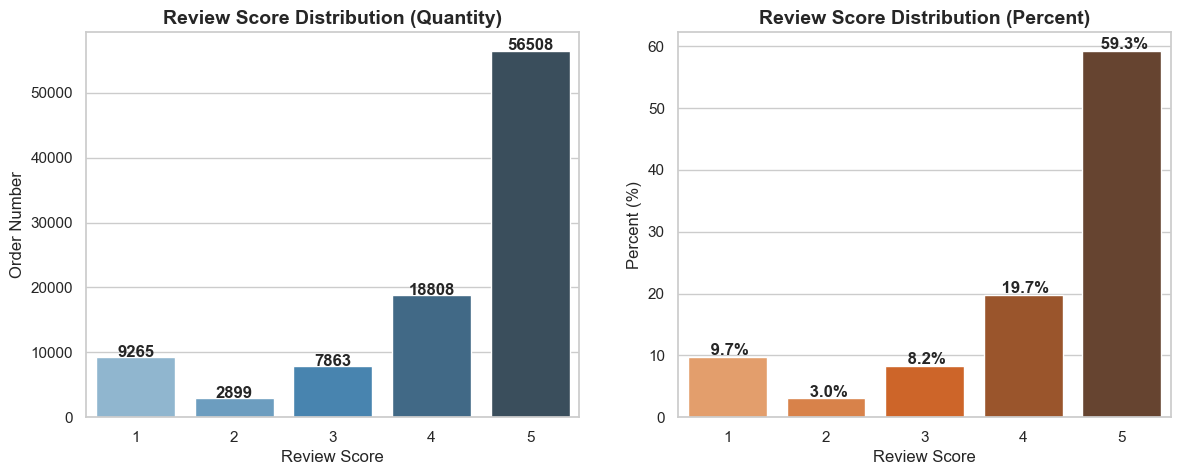

In [8]:
# Set up plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Plot: Review Score (Quantity)
sns.barplot(x = target_count.index, y = target_count.values, palette= 'Blues_d', ax = axes[0])
axes[0].set_title('Review Score Distribution (Quantity)', fontweight = 'bold', fontsize = 14)
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Order Number')
for i, v in enumerate(target_count.values):
    axes[0].text(i, v + 100, str(v), ha = 'center', fontweight = 'bold')

# Right Plot: Review Score (Percent)
sns.barplot(x = target_percent.index, y = target_percent.values, palette= 'Oranges_d', ax = axes[1])
axes[1].set_title('Review Score Distribution (Percent)', fontweight = 'bold', fontsize = 14)
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Percent (%)')
for i, v in enumerate(target_percent.values):
    axes[1].text(i, v + 0.3, f'{v: .1f}%', ha = 'center', fontweight = 'bold')
plt.show()

In [9]:
satisfied_count = train_df['is_satisfied'].value_counts()
print(satisfied_count)
rate_satisfied = train_df['is_satisfied'].mean()
print(f"Level of satisfaction found: {rate_satisfied: .2%}")

is_satisfied
0    75316
1    20027
Name: count, dtype: int64
Level of satisfaction found:  21.01%


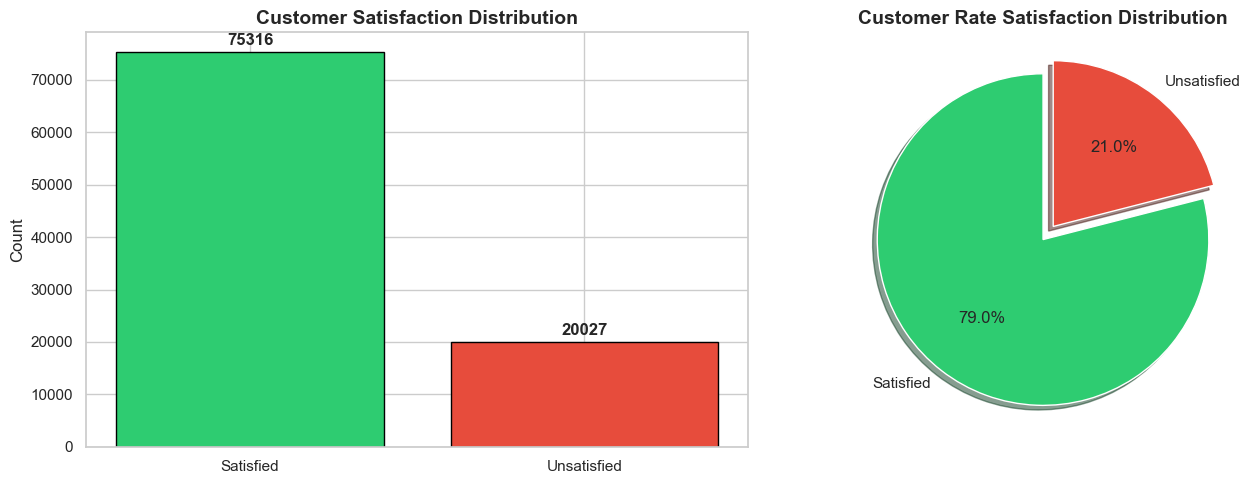

In [10]:
# 1. Prepare Data
labels = ['Satisfied', 'Unsatisfied']
colors = ['#2ecc71', '#e74c3c']

# 2. Create the layout(1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize = (14,5))

# Left Plot
bar = axes[0].bar(labels, satisfied_count, color = colors, edgecolor = 'black')
axes[0].set_title("Customer Satisfaction Distribution", fontweight = 'bold', fontsize = 14)
axes[0].set_ylabel("Count")
axes[0].bar_label(bar, padding=3, fontweight='bold')

# Right Plot
axes[1].pie(satisfied_count, labels = labels, autopct = '%1.1f%%', colors = colors, startangle = 90, explode = (0, 0.1), shadow = True)
axes[1].set_title("Customer Rate Satisfaction Distribution", fontweight = 'bold', fontsize = 14)

plt.tight_layout()
plt.show()

Analysis of the review_score distribution reveals a significant class imbalance:

- 5-star ratings account for 59.3% of all reviews, making them the dominant category and significantly outweighing the remaining rating levels.
- 1-star ratings represent 9.7% of the reviews, which is considerably higher than the proportion of 2-star ratings (3.0%).
- This pattern suggests that customers tend to provide polarized feedback, expressing either very high satisfaction or very strong dissatisfaction rather than selecting intermediate rating levels.
- Such a tendency toward extreme ratings is a common phenomenon in online review datasets, where users are more motivated to leave feedback when they have either exceptionally positive or exceptionally negative experiences.

## 2.3 Delivery Delay: Distribution & Impact on Satisfaction

In [11]:
def mann_whitney_test(df, feature, target='is_satisfied', label=None):
    dist_sat = df.loc[df[target] == 0, feature].dropna()
    dist_unsat = df.loc[df[target] == 1, feature].dropna()

    stat, p = stats.mannwhitneyu(dist_sat, dist_unsat, alternative='two-sided')
    n1, n2 = len(dist_sat), len(dist_unsat)
    r = 1 - (2 * stat) / (n1 * n2)
    effect = ('negligible' if abs(r) < 0.1 else 'small' if abs(r) < 0.3 else 'medium' if abs(r) < 0.5 else 'large')

    name = label or feature
    print(f"Mann-Whitney U Test — {name}:")
    print(f"Statistic = {stat:,.0f} | p-value = {p:.4f}")
    print(f"{'Statistically significant difference' if p < 0.05 else 'No significant difference'} (alpha = 0.05)")
    print(f"Effect size (r) = {r:.4f} ({effect})")

In [12]:
print("Delivery Delay Days Summary:")
display(train_df['delivery_delay_days'].describe())

Delivery Delay Days Summary:


count    95343.000000
mean       -11.908771
std         10.105992
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64

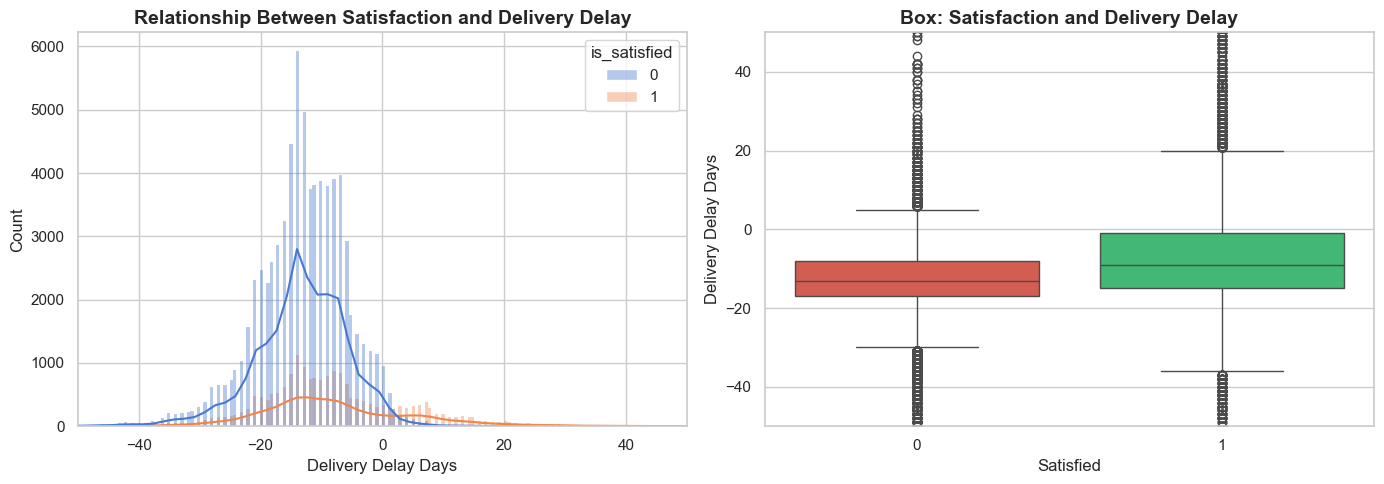

In [13]:
# Set up plot
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Left: Relationship between satisfaction and delivery delay (histogram)
sns.histplot(data = train_df, x = 'delivery_delay_days', hue = 'is_satisfied', kde = True, alpha = 0.4, ax = axes[0])
axes[0].set_title("Relationship Between Satisfaction and Delivery Delay", fontweight = 'bold', fontsize = 14)
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Delivery Delay Days")
axes[0].set_xlim(-50, 50)

# Right: Relationship between satisfaction and delivery delay (boxplot)
sns.boxplot(data=train_df, x='is_satisfied', y='delivery_delay_days', palette=['#e74c3c','#2ecc71'], ax = axes[1])
axes[1].set_title("Box: Satisfaction and Delivery Delay", fontweight = 'bold', fontsize = 14)
axes[1].set_xlabel("Satisfied")
axes[1].set_ylabel("Delivery Delay Days")
axes[1].set_ylim(-50, 50)
plt.tight_layout()
plt.show()

In [14]:
# Mann-Whitney U Test for delivery delay
mann_whitney_test(train_df, 'delivery_delay_days', target='is_satisfied', label='Delay (days)')
print('==' * 25)

# Bin delivery delay into 2 groups: Low and High
train_df['delivery_bin'] = pd.qcut(train_df['delivery_delay_days'], q=2, labels=['Low', 'High'])

# Analyze satisfaction rate by delivery delay bins
delivery_stats = train_df.groupby('delivery_bin', observed=True)['is_satisfied'].agg(count='count', unsat_rate='mean').reset_index()
print("\nDelivery Delay Bins:")
print(delivery_stats)
print('==' * 25)

# Print delivery delay stats for each bin
print("\nDelivery Delay by Satisfaction:")
print(train_df.groupby('delivery_bin', observed=True)['delivery_delay_days'].agg(['min','max','mean']).round(1))
print('==' * 25)

Mann-Whitney U Test — Delay (days):
Statistic = 564,101,314 | p-value = 0.0000
Statistically significant difference (alpha = 0.05)
Effect size (r) = 0.2520 (small)

Delivery Delay Bins:
  delivery_bin  count  unsat_rate
0          Low  52015    0.162415
1         High  43328    0.267241

Delivery Delay by Satisfaction:
              min  max  mean
delivery_bin                
Low          -147  -12 -18.1
High          -11  188  -4.4


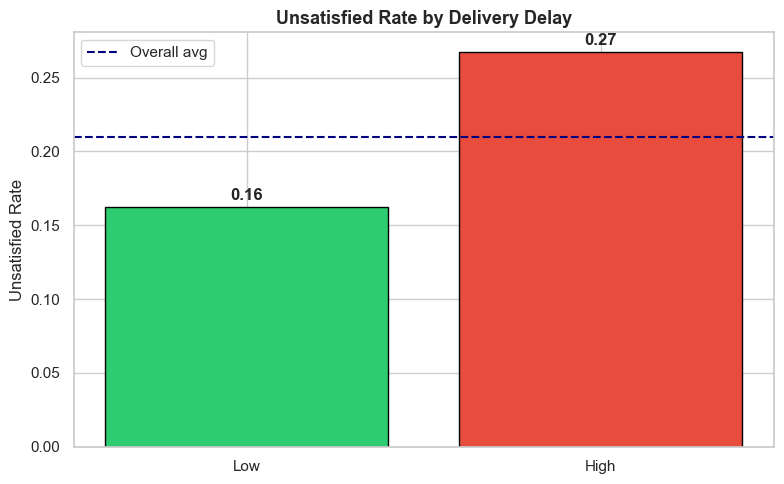

In [15]:
plt.figure(figsize=(8, 5))

# Bar — unsatisfied rate for each delivery delay bin
bars = plt.bar(delivery_stats['delivery_bin'].astype(str), delivery_stats['unsat_rate'], color=colors, edgecolor='black')
plt.bar_label(bars, fmt='%.2f', padding=3, fontweight='bold')
plt.axhline(train_df['is_satisfied'].mean(), color='navy', linestyle='--', label='Overall avg')
plt.title('Unsatisfied Rate by Delivery Delay', fontweight='bold', fontsize=13)
plt.ylabel('Unsatisfied Rate'); plt.legend()

plt.tight_layout()
plt.show()

- Delivery delay is strongly associated with customer satisfaction. Orders delivered much earlier than expected have a significantly lower dissatisfaction rate than orders delivered closer to the estimated date or late.
- The Mann–Whitney U test indicates a statistically significant difference (p < 0.001), confirming that delivery performance is an important factor influencing customer satisfaction.
- Overall, earlier deliveries tend to receive more positive reviews, making delivery_delay_days one of the most influential features for predicting customer satisfaction.

## 2.4 Geographic Distance Analysis (Haversine)

### Geographic Distance using Haversine Formula
$d = 2R \cdot \arcsin\left(\sqrt{\sin^2\left(\frac{\Delta \varphi}{2}\right) + \cos(\varphi_1)\cos(\varphi_2)\sin^2\left(\frac{\Delta \lambda}{2}\right)}\right)$
- $R$: bán kính Trái Đất (≈ 6371 km)  
- $\varphi$: vĩ độ (latitude)  
- $\lambda$: kinh độ (longitude)

In [16]:
def haversine_formula(lat1, lon1, lat2, lon2):
    #Convert Radient
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371
    return c * r

# Apply distance calculation to the entire dataframe
train_df['distance_km'] = haversine_formula(train_df['customer_lat'], train_df['customer_lng'], train_df['seller_lat'], train_df['seller_lng'])

                     delivery_delay_days  distance_km
delivery_delay_days             1.000000    -0.076107
distance_km                    -0.076107     1.000000


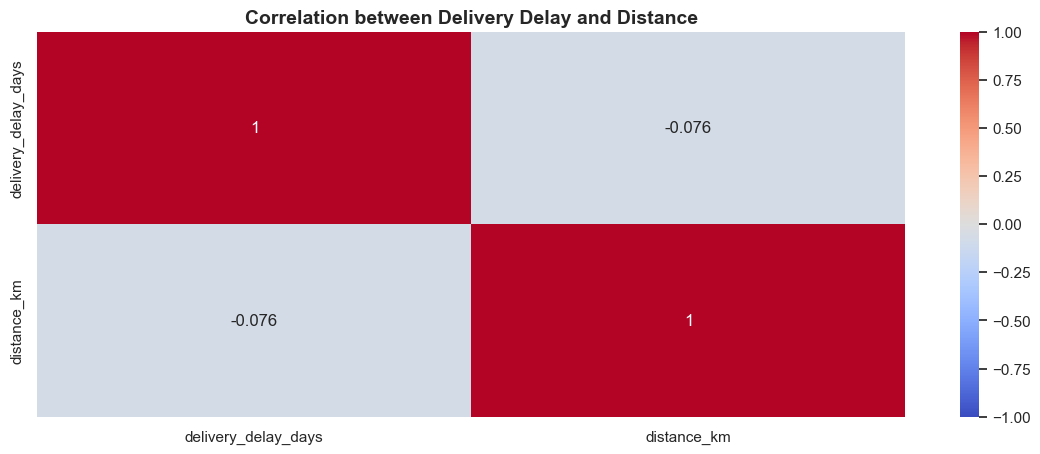

In [17]:
# Correlation between Delivery Delay and Distance
corr_value = train_df[['delivery_delay_days', 'distance_km']].corr()
print(corr_value)

# Correlation Plot
plt.figure(figsize= (14,5))
sns.heatmap(corr_value, cmap= 'coolwarm', annot = True, center= 0, vmin = -1, vmax= 1)
plt.title('Correlation between Delivery Delay and Distance', fontweight = 'bold', fontsize = 14)
plt.show() 

In [18]:
# Mann-Whitney U Test — distance_km vs satisfaction
mann_whitney_test(train_df, 'distance_km', target='is_satisfied', label='Distance (km)')

Mann-Whitney U Test — Distance (km):
Statistic = 692,404,295 | p-value = 0.0000
Statistically significant difference (alpha = 0.05)
Effect size (r) = 0.0727 (negligible)


- Distance between customers and sellers has a very weak relationship with delivery delay and customer satisfaction
- Although the Mann–Whitney U test shows statistical significance (p < 0.001), the effect size is negligible (r = 0.073), indicating little practical importance.
- Therefore, distance_km has limited predictive value for customer satisfaction and may be considered for removal or combination with other features during feature selection.

# 3. Order Value & Shipping Cost

## 3.1 Total Order Value vs Customer Satisfaction

In [19]:
# Mann-Whitney U Test — Statistical test for total_order_value vs satisfaction
mann_whitney_test(train_df, 'total_order_value', target='is_satisfied', label='Total Order Value')
print('==' * 25)

# Bin total order value into 3 groups: Low, Medium, High
train_df['total_order_bins'] = pd.qcut(train_df['total_order_value'], q=3, labels=['Low', 'Medium', 'High'])

# Group by total order bins and calculate count and unsatisfied rate
order_stats = train_df.groupby('total_order_bins', observed=True)['is_satisfied'].agg(count='count', unsat_rate='mean').reset_index()
print("\nTotal Order Value Bins:")
print(order_stats)
print('==' * 25)

# Print total order value stats for each bin
print("\nTotal Order Value by Satisfaction:")
print(train_df.groupby('total_order_bins', observed=True)['total_order_value'].agg(['min','max','mean']).round(1))
print('==' * 25)

Mann-Whitney U Test — Total Order Value:
Statistic = 706,786,360 | p-value = 0.0000
Statistically significant difference (alpha = 0.05)
Effect size (r) = 0.0628 (negligible)

Total Order Value Bins:
  total_order_bins  count  unsat_rate
0              Low  31789    0.191418
1           Medium  31771    0.206100
2             High  31780    0.232631

Total Order Value by Satisfaction:
                    min      max   mean
total_order_bins                       
Low                 9.6     73.4   49.1
Medium             73.4    147.3  106.8
High              147.3  13664.1  323.4


,count,mean,std,min,25%,50%,75%,max
is_satisfied,,,,,,,,
0,75314.0,156.07,208.24,9.59,61.00,103.26,173.05,6929.31
1,20026.0,173.56,250.30,10.89,65.11,112.66,191.21,13664.08


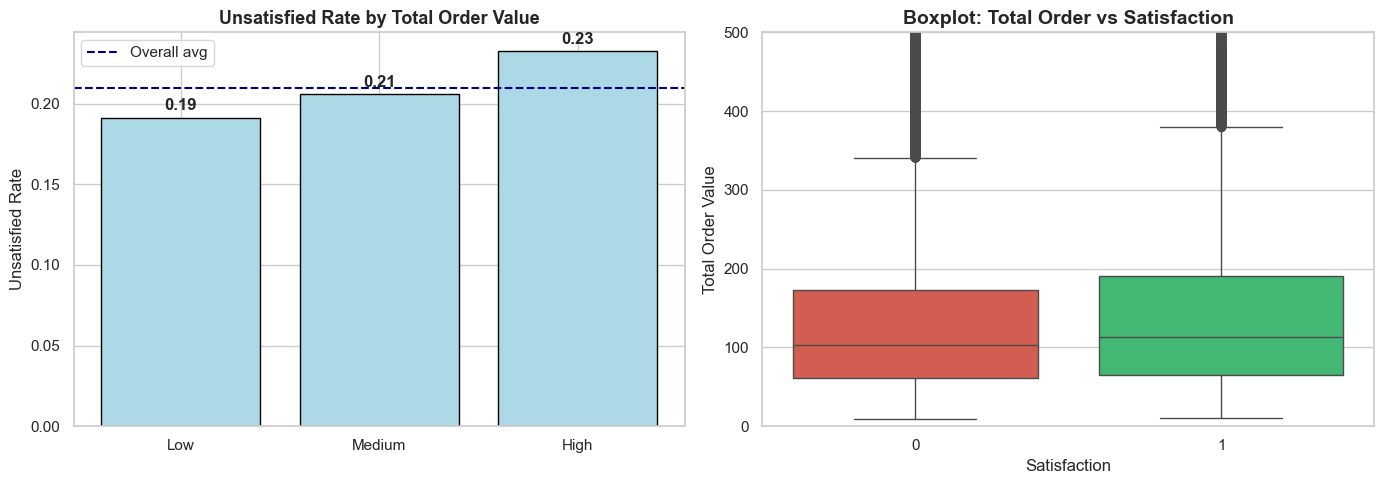

In [20]:
display(train_df.groupby('is_satisfied')['total_order_value'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left 
bars = axes[0].bar(order_stats['total_order_bins'].astype(str), order_stats['unsat_rate'], color= 'lightblue', edgecolor='black')
axes[0].bar_label(bars, fmt='%.2f', padding=3, fontweight='bold')
axes[0].axhline(train_df['is_satisfied'].mean(), color='navy', linestyle='--', label='Overall avg')
axes[0].set_title('Unsatisfied Rate by Total Order Value', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Unsatisfied Rate')
axes[0].legend()

# Right
sns.boxplot(data=train_df, x='is_satisfied', y='total_order_value', palette=['#e74c3c','#2ecc71'], ax=axes[1])
axes[1].set_title("Boxplot: Total Order vs Satisfaction", fontweight='bold', fontsize=14)
axes[1].set_xlabel('Satisfaction')
axes[1].set_ylabel('Total Order Value')
axes[1].set_ylim(0,500)

plt.tight_layout()
plt.show()

- Customers who are dissatisfied tend to have slightly higher total order values (173.56 vs 156.07), and the difference is statistically significant but with a negligible effect size (r = 0.063).
- When grouped into Low / Medium / High order value, the dissatisfaction rate shows a gradual increase (19.1% → 20.6% → 23.3%).
- Overall, higher-value orders are associated with a slight increase in dissatisfaction, possibly due to higher customer expectations, but the relationship is weak and not practically strong.

## 3.2 Freight Cost vs Customer Satisfaction

In [21]:
# Mann-Whitney U Test — statistical test for freight_value vs satisfaction
mann_whitney_test(train_df, 'total_freight_value', target='is_satisfied', label='Total Freight Value')
print('==' * 25)

# Bin total order value into 4 groups: Low, Medium, High, Very High
train_df['freight_value_bin'] = pd.qcut(train_df['total_freight_value'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Group by freight value bins and calculate count and unsatisfied rate
bin_stats = (train_df.groupby('freight_value_bin', observed=True)['is_satisfied'].agg(count='count', unsat_rate=lambda x: x.mean()).reset_index())
print("\nFreight Value Bins:")
print(bin_stats)
print('==' * 25)

# Print freight value stats for each bin
print("\nFreight Value by Satisfaction:")
print(train_df.groupby('freight_value_bin', observed=True)['total_freight_value'].agg(['min','max','mean']).round(1))
print('==' * 25)

Mann-Whitney U Test — Total Freight Value:
Statistic = 659,169,286 | p-value = 0.0000
Statistically significant difference (alpha = 0.05)
Effect size (r) = 0.1260 (small)

Freight Value Bins:
  freight_value_bin  count  unsat_rate
0          Very Low  19085    0.165523
1               Low  19078    0.191005
2            Medium  19065    0.202413
3              High  19051    0.210068
4         Very High  19064    0.281316

Freight Value by Satisfaction:
                    min     max  mean
freight_value_bin                    
Very Low            0.0    12.8   9.7
Low                12.8    15.6  14.5
Medium             15.6    18.6  17.2
High               18.6    27.4  22.2
Very High          27.4  1795.0  50.3


,count,mean,std,min,25%,50%,75%,max
is_satisfied,,,,,,,,
0,75316.0,21.88,19.76,0.0,13.59,16.87,23.29,1794.96
1,20027.0,26.10,26.96,0.0,14.70,18.20,28.44,1002.29


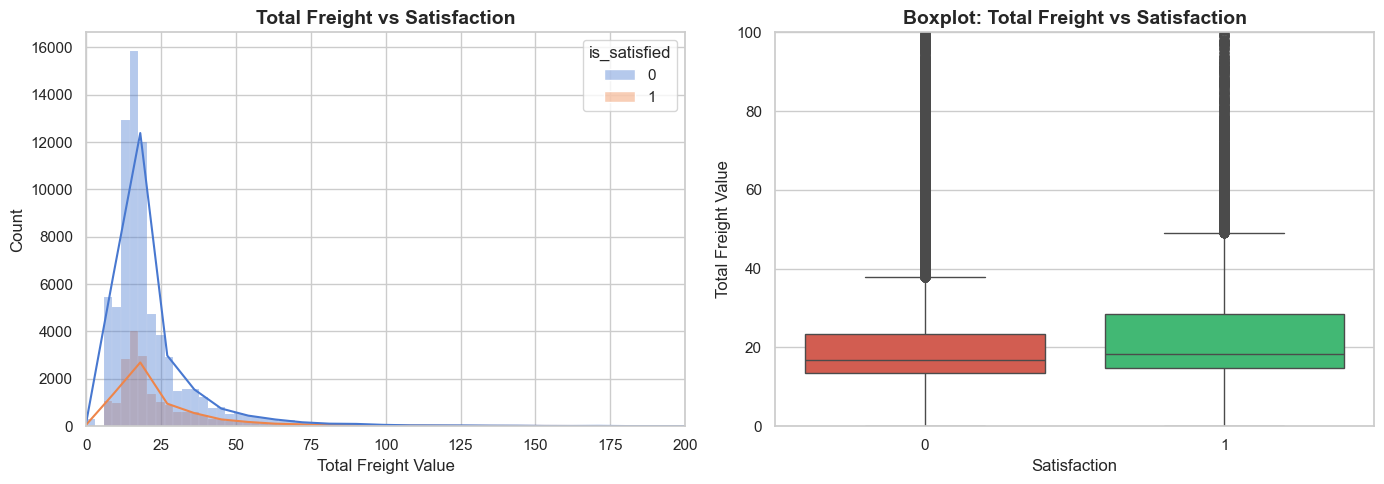

In [22]:
display(train_df.groupby('is_satisfied')['total_freight_value'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left 
sns.histplot(data=train_df, x='total_freight_value', hue='is_satisfied', kde=True, alpha=0.4, ax=axes[0])
axes[0].set_title("Total Freight vs Satisfaction", fontweight='bold', fontsize=14)
axes[0].set_xlabel('Total Freight Value')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 200)

# Right
sns.boxplot(data=train_df, x='is_satisfied', y='total_freight_value', palette=['#e74c3c','#2ecc71'], ax=axes[1])
axes[1].set_title("Boxplot: Total Freight vs Satisfaction", fontweight='bold', fontsize=14)
axes[1].set_xlabel('Satisfaction')
axes[1].set_ylabel('Total Freight Value')
axes[1].set_ylim(0,100)
plt.tight_layout()
plt.show()

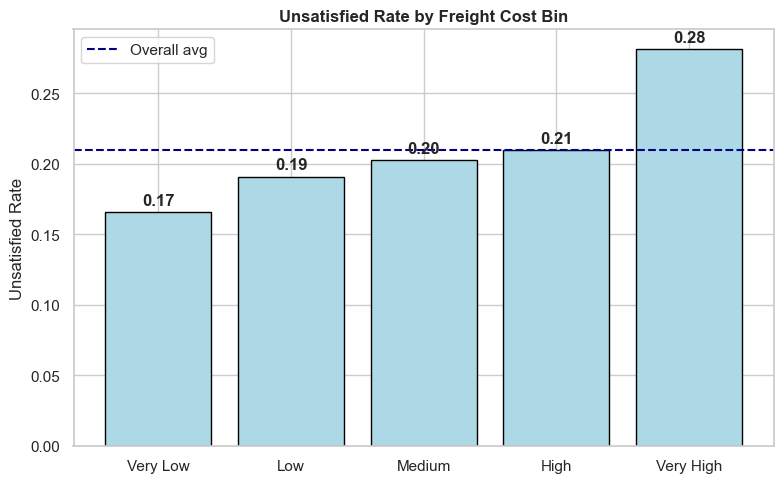

In [23]:
plt.figure(figsize=(8, 5))

bars = plt.bar(bin_stats['freight_value_bin'].astype(str), bin_stats['unsat_rate'], color= ['lightblue'], edgecolor='black')
plt.bar_label(bars, fmt='%.2f', padding=3, fontweight='bold')
plt.axhline(train_df['is_satisfied'].mean(), color='navy', linestyle='--', label='Overall avg')
plt.title('Unsatisfied Rate by Freight Cost Bin', fontweight='bold')
plt.ylabel('Unsatisfied Rate'); plt.legend()
plt.tight_layout()
plt.show()

- Freight cost shows a clearer relationship with customer dissatisfaction compared to other financial features, with a small effect size (r = 0.126).
- The dissatisfaction rate increases steadily across freight groups: Very Low (16.6%) → Low (19.1%) → Medium (20.2%) → High (21.0%) → Very High (28.1%), with the highest group showing about 11.6 percentage points higher dissatisfaction than the lowest.
- On average, dissatisfied customers also face higher freight costs (26.10 vs 21.88).
- Overall, higher shipping costs are associated with lower customer satisfaction, likely because customers perceive high freight fees negatively when not matched by perceived value or service quality.

## 3.3 Freight Ratio vs Customer Satisfaction

In [24]:
# Mann-Whitney U Test — statics freight ratio
mann_whitney_test(train_df, 'freight_ratio', target='is_satisfied', label='Freight Ratio')
print('==' * 25)

# Bin freight ratio into 3 groups: Low, Medium, High
train_df['freight_ratio_bin'] = pd.qcut(train_df['freight_ratio'], q=3, labels=['Low', 'Medium', 'High'])

# Group by freight ratio bins and calculate count and unsatisfied rate
freight_bin_stats = (train_df.groupby('freight_ratio_bin', observed=True)['is_satisfied'].agg(count='count', unsat_rate=lambda x: x.mean()).reset_index())
print("\nFreight Ratio Bins:")
print(freight_bin_stats)
print('==' * 25)

# Print freight ratio stats for each bin
print("\nFreight Ratio by Satisfaction:")
print(train_df.groupby('freight_ratio_bin', observed=True)['freight_ratio'].agg(['min','max','mean']).round(2))
print('==' * 25)

Mann-Whitney U Test — Freight Ratio:
Statistic = 724,303,788 | p-value = 0.0000
Statistically significant difference (alpha = 0.05)
Effect size (r) = 0.0395 (negligible)

Freight Ratio Bins:
  freight_ratio_bin  count  unsat_rate
0               Low  31781    0.196721
1            Medium  31782    0.209395
2              High  31777    0.224030

Freight Ratio by Satisfaction:
                    min   max  mean
freight_ratio_bin                  
Low                0.00  0.14  0.09
Medium             0.14  0.24  0.18
High               0.24  0.96  0.35


,count,mean,std,min,25%,50%,75%,max
is_satisfied,,,,,,,,
0,75314.0,0.21,0.12,0.0,0.12,0.18,0.27,0.96
1,20026.0,0.22,0.13,0.0,0.12,0.19,0.28,0.86


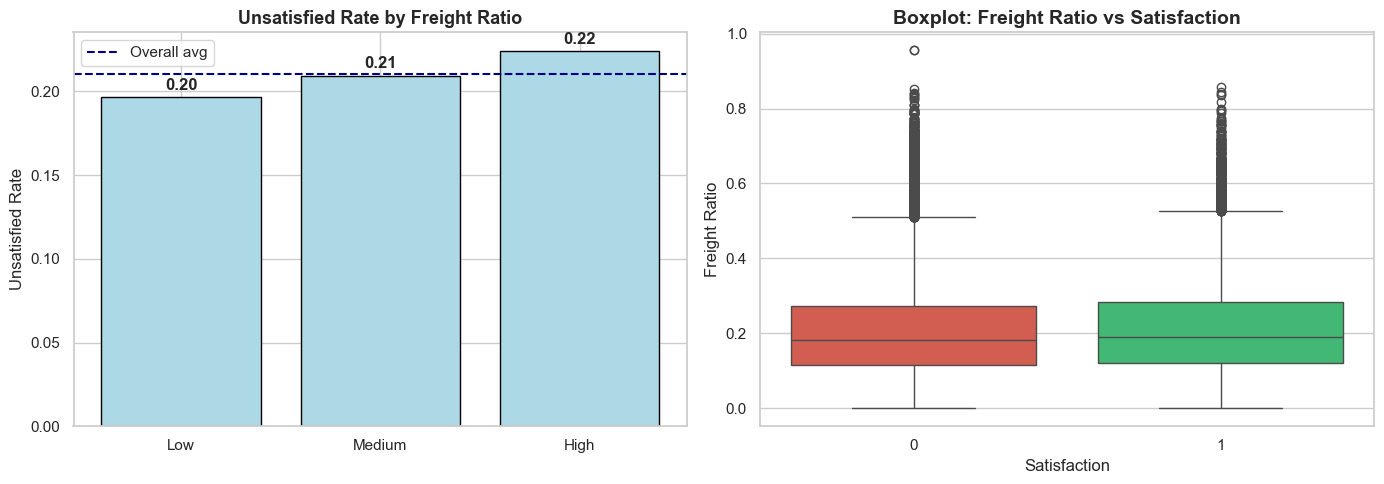

In [25]:
display(train_df.groupby('is_satisfied')['freight_ratio'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left 
bars = axes[0].bar(freight_bin_stats['freight_ratio_bin'].astype(str), freight_bin_stats['unsat_rate'], color= 'lightblue', edgecolor='black')
axes[0].bar_label(bars, fmt='%.2f', padding=3, fontweight='bold')
axes[0].axhline(train_df['is_satisfied'].mean(), color='navy', linestyle='--', label='Overall avg')
axes[0].set_title('Unsatisfied Rate by Freight Ratio', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Unsatisfied Rate')
axes[0].legend()

# Right
sns.boxplot(data=train_df, x='is_satisfied', y='freight_ratio', palette=['#e74c3c','#2ecc71'], ax=axes[1])
axes[1].set_title("Boxplot: Freight Ratio vs Satisfaction", fontweight='bold', fontsize=14)
axes[1].set_xlabel('Satisfaction')
axes[1].set_ylabel('Freight Ratio')

plt.tight_layout()
plt.show()

- Freight ratio shows a very weak relationship with customer satisfaction, despite being statistically significant, with a negligible effect size (r = 0.040).
- The dissatisfaction rates across Low / Medium / High groups are very close (19.7% → 20.9% → 22.4%), and the average values between satisfied and dissatisfied customers are almost identical (0.21 vs 0.22).
- Overall, freight ratio is a weak predictor of satisfaction, suggesting that customers react more to the absolute shipping cost rather than its proportion relative to order value.

# 4.  Payment Analysis

## 4.1 Payment Method Distribution & Satisfaction Rate

In [26]:
payment_stats = (train_df.groupby('payment_type')['is_satisfied']
    .agg(total='count', sat_rate=lambda x: x.mean() * 100)
    .sort_values('sat_rate', ascending=False)
    .reset_index()
)
print(payment_stats)

  payment_type  total   sat_rate
0  not_defined      3  33.333333
1      voucher   2939  22.592719
2       boleto  18983  21.108360
3  credit_card  71946  20.958775
4   debit_card   1472  18.750000


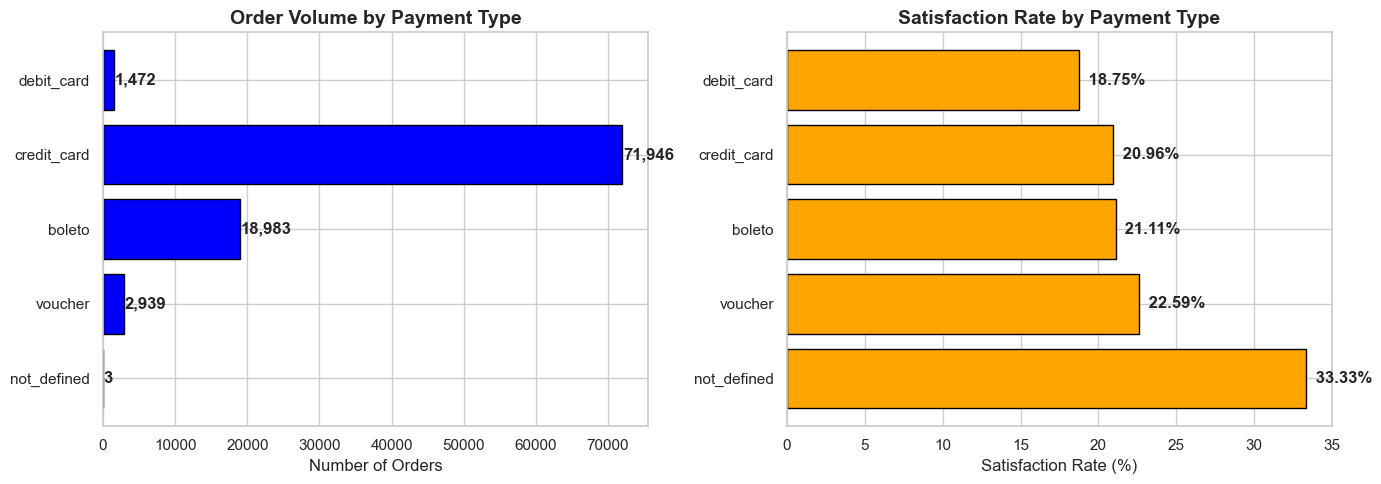

In [27]:
fig, axes = plt.subplots(1, 2, figsize = (14,5))

#
bars = axes[0].barh(payment_stats['payment_type'], payment_stats['total'], color = 'blue', edgecolor = 'black' )
axes[0].set_title('Order Volume by Payment Type', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Number of Orders')
for bar, val in zip(bars, payment_stats['total']):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2, f'{val:,}', va='center', fontweight='bold')

#
bars = axes[1].barh(payment_stats['payment_type'], payment_stats['sat_rate'], color = 'orange', edgecolor = 'black')
axes[1].set_title('Satisfaction Rate by Payment Type', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Satisfaction Rate (%)')
for bar, val in zip(bars, payment_stats['sat_rate']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f'{val: .2f}%', va = 'center', fontweight = 'bold')
plt.tight_layout()
plt.show()

- Customer satisfaction varies only slightly across payment methods, with all major groups showing similar rates.
- Satisfaction ranking is: debit_card (81.25%) > credit_card (79.04%) > boleto (78.89%) > voucher (77.41%), while not_defined is not statistically meaningful due to very small sample size.
- The differences among common payment methods are only about 2–3 percentage points, indicating that payment method is not a strong driver of customer satisfaction.

## 4.2 Number of Installments vs Satisfaction

In [28]:
installment_stats = (train_df.groupby('payment_installments')['is_satisfied']
    .agg(total='count', satisfaction_rate=lambda x: x.mean() * 100)
    .reset_index()
)
installment_stats = installment_stats[installment_stats['total'] >= 50]
print(installment_stats)

    payment_installments  total  satisfaction_rate
0                    1.0  44418          19.850061
1                    2.0  13100          20.763359
2                    3.0  10263          21.942902
3                    4.0   6928          22.257506
4                    5.0   5081          22.357804
5                    6.0   3783          21.438012
6                    7.0   1600          21.750000
7                    8.0   4055          22.737361
8                    9.0    653          20.061256
9                   10.0   4963          24.622204
10                  11.0    118          27.966102
11                  12.0    139          21.582734
14                  15.0     73          21.917808


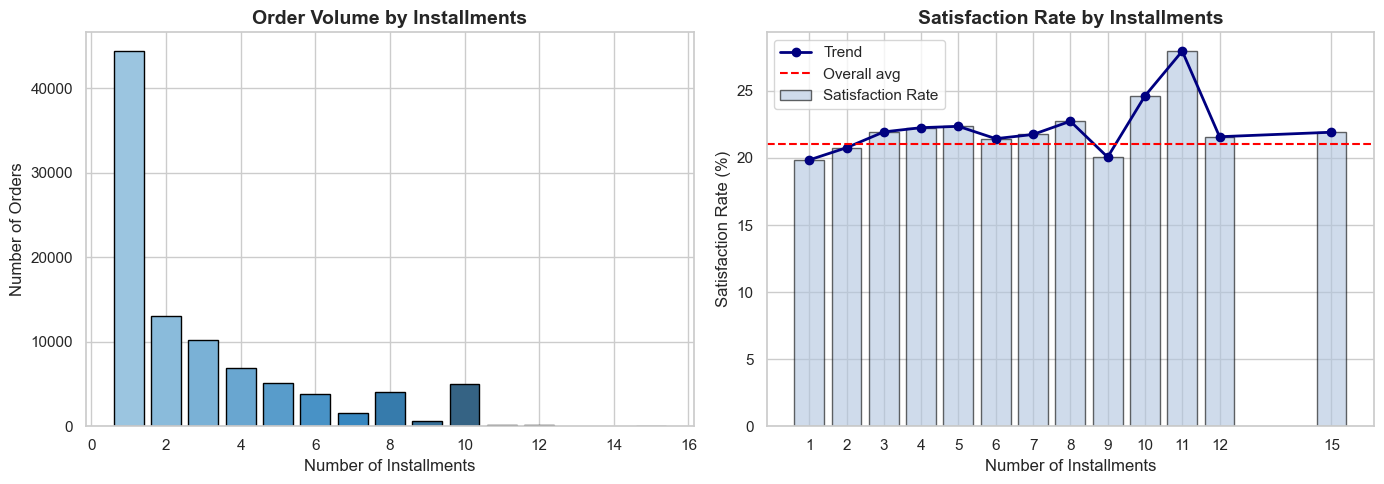

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Left: Volume theo installment
axes[0].bar(installment_stats['payment_installments'], installment_stats['total'], color = sns.color_palette('Blues_d', len(installment_stats)), edgecolor = 'black')
axes[0].set_title('Order Volume by Installments', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Number of Installments')
axes[0].set_ylabel('Number of Orders')

# Right: Satisfaction rate theo installment (line + bar)
axes[1].bar(installment_stats['payment_installments'], installment_stats['satisfaction_rate'], color='lightsteelblue', edgecolor='black', 
            alpha=0.6, label='Satisfaction Rate')
axes[1].plot(installment_stats['payment_installments'], installment_stats['satisfaction_rate'], marker='o', color='navy', linewidth=2, label='Trend')
axes[1].axhline(train_df['is_satisfied'].mean() * 100, color='red', linestyle='--', linewidth=1.5, label='Overall avg')
axes[1].set_title('Satisfaction Rate by Installments', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Number of Installments')
axes[1].set_ylabel('Satisfaction Rate (%)')
axes[1].set_xticks(installment_stats['payment_installments'])
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. Product & Category

## 5.1 Category-Level Satisfaction Analysis

In [ ]:
category = train_df.groupby('category_name_english')['is_satisfied'].agg(total = 'count', rate = lambda x: x.mean() * 100).sort_values('rate', ascending = False)

In [31]:
category.head(10)

,total,rate
category_name_english,,
security_and_services,2,50.000000
office_furniture,1229,36.371033
fashio_female_clothing,36,33.333333
audio,342,30.994152
home_confort,381,30.708661
fashion_male_clothing,105,29.523810
home_comfort_2,21,28.571429
diapers_and_hygiene,25,28.000000
furniture_mattress_and_upholstery,36,27.777778


In [32]:
category.tail(10)

,total,rate
category_name_english,,
books_technical,254,12.992126
small_appliances_home_oven_and_coffee,71,12.676056
books_imported,49,12.244898
flowers,27,11.111111
books_general_interest,489,9.815951
costruction_tools_tools,94,9.574468
la_cuisine,11,9.090909
cds_dvds_musicals,12,8.333333
fashion_sport,24,8.333333


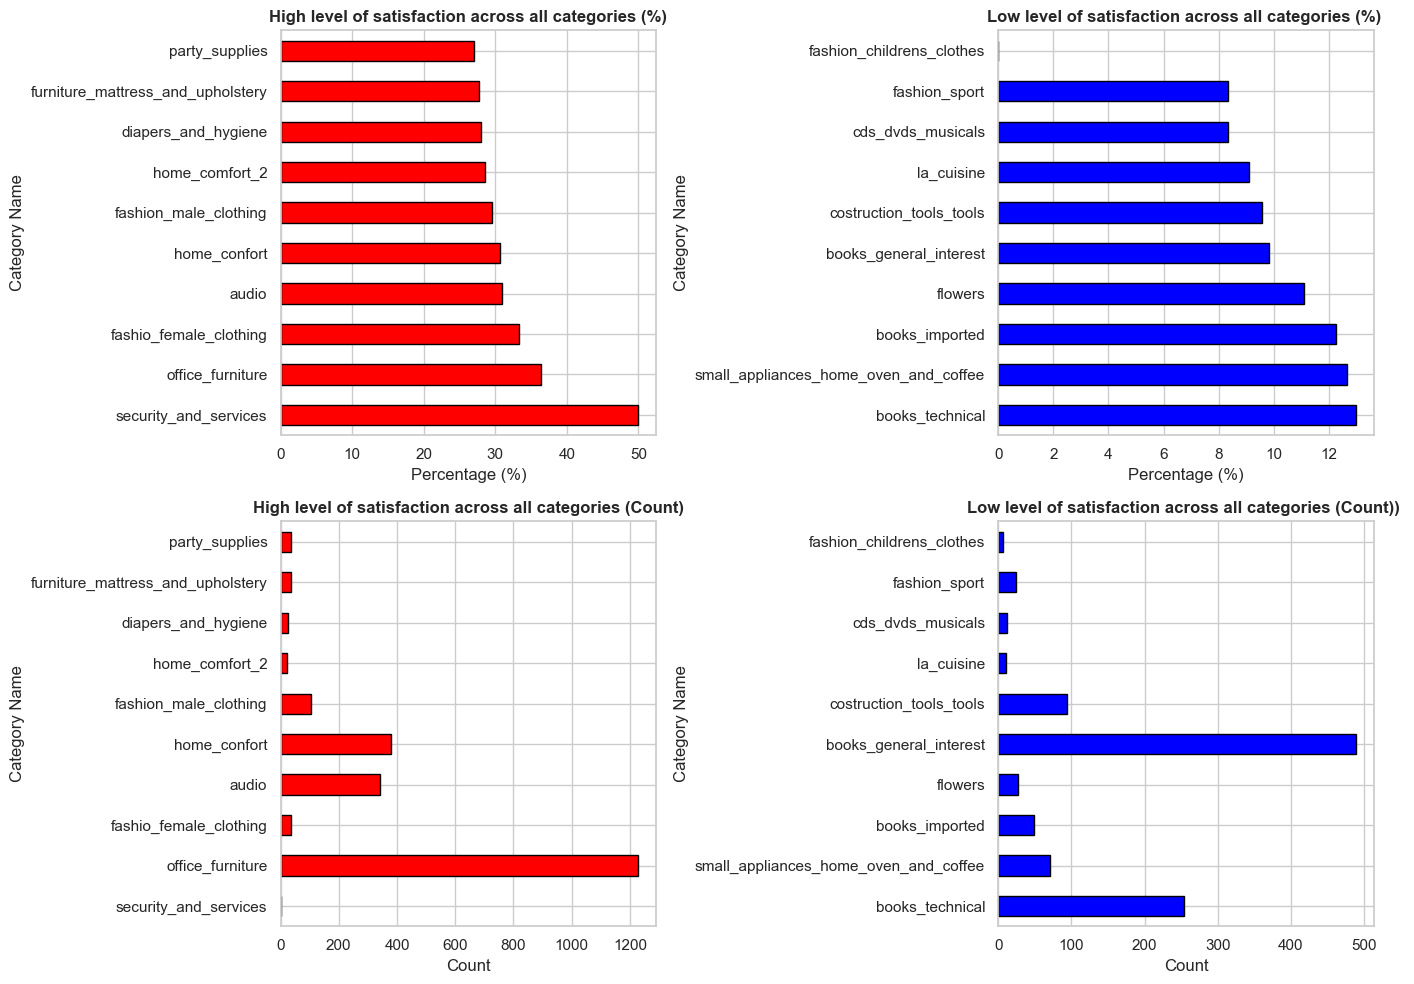

In [33]:
# Create Plot
fig, axes = plt.subplots(2, 2, figsize = (14, 10))

# Chart 1: Rate (hight)
category['rate'].head(10).plot(kind = 'barh',ax = axes[0][0], color = 'red', edgecolor = 'black')
axes[0][0].set_title('High level of satisfaction across all categories (%)', fontweight='bold')
axes[0][0].set_ylabel('Category Name')
axes[0][0].set_xlabel('Percentage (%)')

# Chart 2: Rate (low)
category['rate'].tail(10).plot(kind = 'barh',ax = axes[0][1], color = 'blue', edgecolor = 'black')
axes[0][1].set_title('Low level of satisfaction across all categories (%) ', fontweight='bold')
axes[0][1].set_ylabel('Category Name')
axes[0][1].set_xlabel('Percentage (%)')

# Chart 3: Total (hight)
category['total'].head(10).plot(kind = 'barh',ax = axes[1][0], color = 'red', edgecolor = 'black')
axes[1][0].set_title('High level of satisfaction across all categories (Count)', fontweight='bold')
axes[1][0].set_ylabel('Category Name')
axes[1][0].set_xlabel('Count')

# Chart 4: Total (low)
category['total'].tail(10).plot(kind = 'barh',ax = axes[1][1], color = 'blue', edgecolor = 'black')
axes[1][1].set_title('Low level of satisfaction across all categories (Count)) ', fontweight='bold')
axes[1][1].set_ylabel('Category Name')
axes[1][1].set_xlabel('Count')
plt.tight_layout()
plt.show()

- Customer dissatisfaction varies significantly across product categories, indicating that product type is a strong factor influencing satisfaction.
- High dissatisfaction categories such as office_furniture (36.4%), audio (31.0%), home_confort (30.7%), and fashion_male_clothing (29.5%) are well above the dataset average (~21%), likely due to issues like quality, size/installation complexity, or higher customer expectations.
- Low dissatisfaction categories such as books (technical/imported/general interest: 9.8%–13.0%) and flowers (11.1%) perform much better than average, likely because they are more standardized and less prone to delivery or quality mismatch issues.
- Overall, product category is a strong differentiating factor in customer satisfaction, reflecting differences in complexity, risk, and expectation levels across product types.

# 6. Seller

## 6.1 Seller Experience & Order Volume vs Satisfaction

In [34]:
# Mann-Whitney U Test — statistical test for seller_total_orders vs satisfaction
mann_whitney_test(train_df, 'seller_total_orders', target='is_satisfied', label='seller_total_orders')
print('==' * 25)

# Bin seller volume into 3 groups: Low, Medium, High
train_df['seller_volume_bin'] = pd.qcut(train_df['seller_total_orders'], q=3, labels=['Low','Medium','High'])

# Group by seller volume bins and calculate count and unsatisfied rate
exp_stats = (train_df.groupby('seller_volume_bin', observed=True)['is_satisfied'].agg(count='count', unsat_rate='mean').reset_index())
print("\nSeller Volume Bins:")
print(exp_stats)
print('==' * 25)

# Range for each seller volume bin
print(train_df.groupby('seller_volume_bin', observed=True)['seller_total_orders'].agg(['min','max','mean']).round(1))
print('==' * 25)

Mann-Whitney U Test — seller_total_orders:
Statistic = 719,235,584 | p-value = 0.0000
Statistically significant difference (alpha = 0.05)
Effect size (r) = 0.0463 (negligible)

Seller Volume Bins:
  seller_volume_bin  count  unsat_rate
0               Low  32114    0.195958
1            Medium  31644    0.210403
2              High  31585    0.224030
                   min   max   mean
seller_volume_bin                  
Low                  1    77   32.8
Medium              78   314  164.1
High               316  1798  909.1


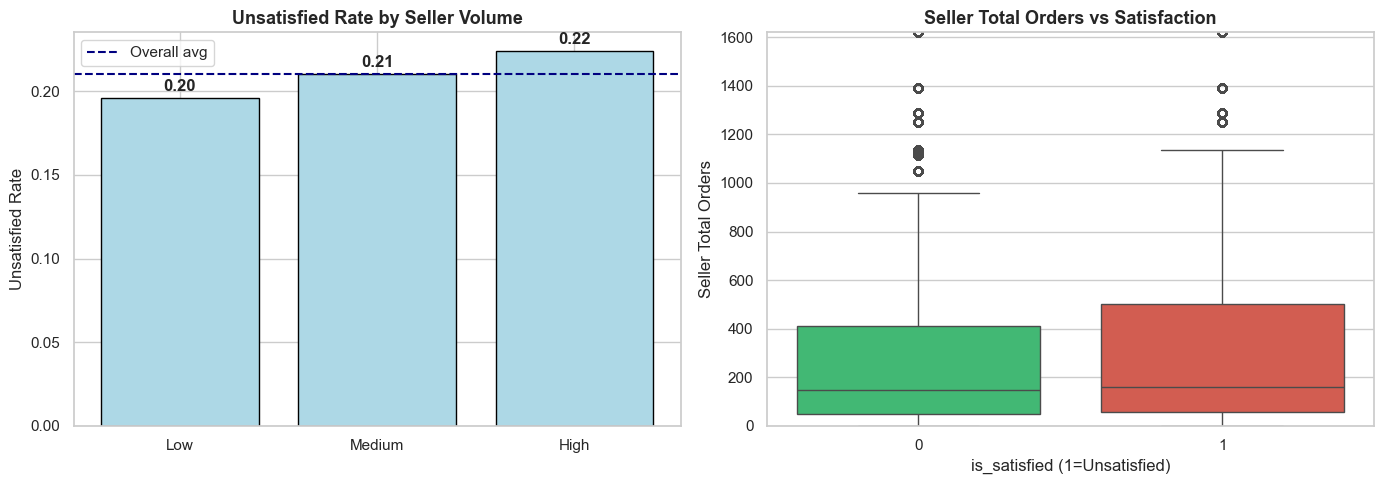

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar — unsatisfied rate theo kinh nghiệm
bars = axes[0].bar(exp_stats['seller_volume_bin'].astype(str), exp_stats['unsat_rate'], color= 'lightblue', edgecolor='black')
axes[0].bar_label(bars, fmt='%.2f', padding=3, fontweight='bold')
axes[0].axhline(train_df['is_satisfied'].mean(), color='navy', linestyle='--', label='Overall avg')
axes[0].set_title('Unsatisfied Rate by Seller Volume', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Unsatisfied Rate')
axes[0].legend()

# Boxplot
sns.boxplot(data=train_df, x='is_satisfied', y='seller_total_orders', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Seller Total Orders vs Satisfaction', fontweight='bold', fontsize=13)
axes[1].set_xlabel('is_satisfied (1=Unsatisfied)')
axes[1].set_ylabel('Seller Total Orders')
axes[1].set_ylim(0, train_df['seller_total_orders'].quantile(0.95))

plt.tight_layout()
plt.show()

## 6.2 Seller Late Delivery Rate vs Satisfaction

In [36]:
# Mann-Whitney U Test — statistical test for seller_late_rate vs satisfaction
mann_whitney_test(train_df, 'seller_late_rate', target='is_satisfied', label='seller_late_rate')
print('==' * 25)

# Bin analysis for seller late rate
train_df['late_rate_bin'] = pd.qcut(
    train_df['seller_late_rate'].clip(upper=train_df['seller_late_rate'].quantile(0.99)),
    q=5, labels=['Very Low','Low','Medium','High','Very High'],
    duplicates='drop'
)

lr_stats = (train_df.groupby('late_rate_bin', observed=True)['is_satisfied'].agg(count='count', unsat_rate='mean').reset_index())
print("\nSeller Late Rate Bins:")
print(lr_stats)
print('==' * 25)

# Range for each seller late rate bin
print("\nSeller Late Rate by Satisfaction:")
print(train_df.groupby('late_rate_bin', observed=True)['seller_late_rate'].agg(['min','max','mean']).round(3))
print('==' * 25)

Mann-Whitney U Test — seller_late_rate:
Statistic = 649,514,492 | p-value = 0.0000
Statistically significant difference (alpha = 0.05)
Effect size (r) = 0.1388 (small)

Seller Late Rate Bins:
  late_rate_bin  count  unsat_rate
0      Very Low  19146    0.151990
1           Low  19328    0.195623
2        Medium  18797    0.205884
3          High  19085    0.221902
4     Very High  18987    0.275504

Seller Late Rate by Satisfaction:
                 min    max   mean
late_rate_bin                     
Very Low       0.000  0.028  0.009
Low            0.028  0.050  0.040
Medium         0.050  0.065  0.057
High           0.065  0.090  0.079
Very High      0.090  1.000  0.139


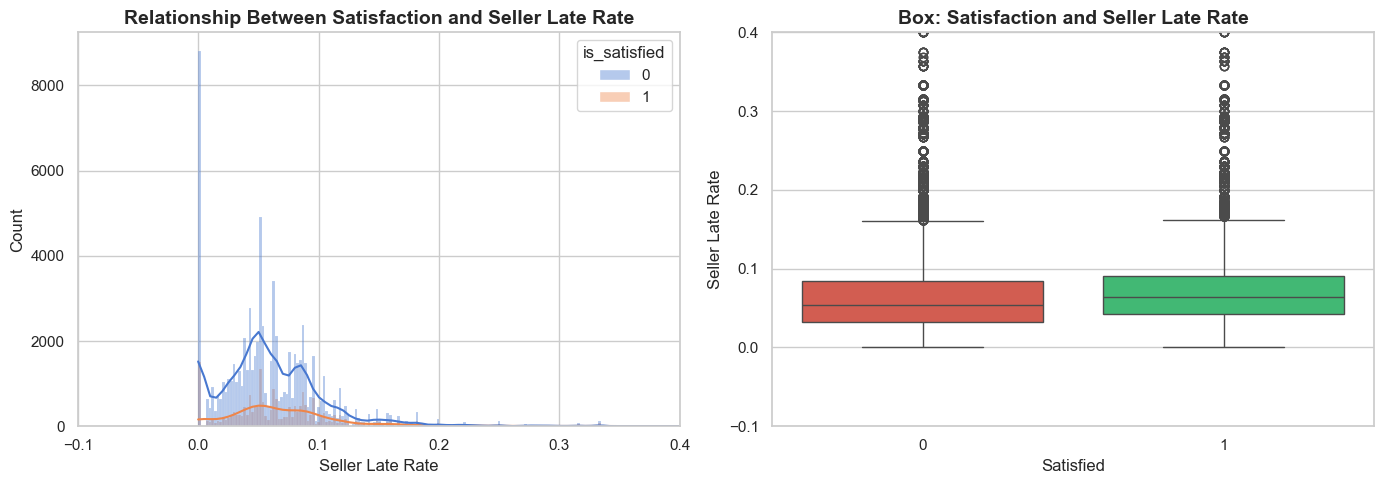

In [37]:
# Set up plot
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Left: Relationship between satisfaction and delivery delay (histogram)
sns.histplot(data = train_df, x = 'seller_late_rate', hue = 'is_satisfied', kde = True, alpha = 0.4, ax = axes[0])
axes[0].set_title("Relationship Between Satisfaction and Seller Late Rate", fontweight = 'bold', fontsize = 14)
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Seller Late Rate")
axes[0].set_xlim(-0.1, 0.4)

# Right: Relationship between satisfaction and delivery delay (boxplot)
sns.boxplot(data=train_df, x='is_satisfied', y='seller_late_rate', palette=['#e74c3c','#2ecc71'], ax = axes[1])
axes[1].set_title("Box: Satisfaction and Seller Late Rate", fontweight = 'bold', fontsize = 14)
axes[1].set_xlabel("Satisfied")
axes[1].set_ylabel("Seller Late Rate")
axes[1].set_ylim(-0.1, 0.4)
plt.tight_layout()
plt.show()

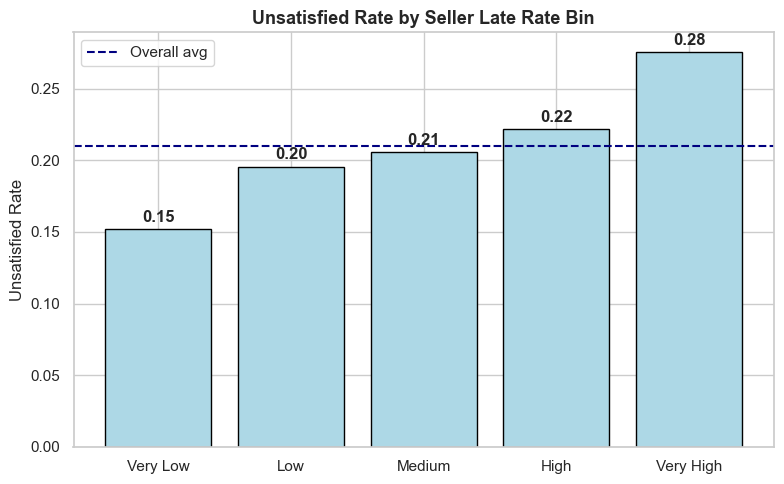

In [38]:
plt.figure(figsize=(8, 5))
bars = plt.bar(lr_stats['late_rate_bin'].astype(str), lr_stats['unsat_rate'], color= 'lightblue', edgecolor='black')
plt.bar_label(bars, fmt='%.2f', padding=3, fontweight='bold')
plt.axhline(train_df['is_satisfied'].mean(), color='navy',linestyle='--', label='Overall avg')
plt.title('Unsatisfied Rate by Seller Late Rate Bin', fontweight='bold', fontsize=13)
plt.ylabel('Unsatisfied Rate')
plt.legend()
plt.tight_layout()
plt.show()

- Seller late delivery rate is one of the strongest predictors of customer dissatisfaction, with a small but meaningful effect size (r = 0.139).
- Dissatisfaction increases consistently across groups: Very Low (15.2%) → Low (19.6%) → Medium (20.6%) → High (22.2%) → Very High (27.6%), with a gap of about 12.4 percentage points between the extremes.
- This pattern is consistent with previous findings on delivery delay, indicating that a seller’s historical operational performance is a stable and important predictor of customer satisfaction.

## 6.3 Seller Average Review Score vs Satisfaction

In [39]:
# Mann-Whitney U Test — statistical test for seller_avg_review_score vs satisfaction
mann_whitney_test(train_df, 'seller_avg_review_score', target='is_satisfied', label='seller_avg_review_score')
print('==' * 25)

# Bin seller average review score into 3 groups: Very Low, Low, Medium, High, Very High
train_df['review_score_bin'] = pd.cut(train_df['seller_avg_review_score'], bins = [1,3,4,5], labels=['Low (1-3)', 'Medium (3-4)', 'High (4-5)'])

score_stats = (train_df.groupby(train_df['review_score_bin'])['is_satisfied'].agg(count='count', unsat_rate='mean').reset_index())
print("\nSeller Average Review Score Bins:")
print(score_stats)
print('==' * 25)

# Print seller average review score stats for each bin
print("\nSeller Average Review Score by Satisfaction:")
print(train_df.groupby(train_df['review_score_bin'])['seller_avg_review_score'].agg(['min','max','mean']).round(2))
print('==' * 25)

Mann-Whitney U Test — seller_avg_review_score:
Statistic = 962,980,628 | p-value = 0.0000
Statistically significant difference (alpha = 0.05)
Effect size (r) = -0.2769 (small)

Seller Average Review Score Bins:
  review_score_bin  count  unsat_rate
0        Low (1-3)   1191    0.581024
1     Medium (3-4)  31662    0.285074
2       High (4-5)  62425    0.164101

Seller Average Review Score by Satisfaction:
                   min  max  mean
review_score_bin                 
Low (1-3)         1.40  3.0  2.67
Medium (3-4)      3.03  4.0  3.81
High (4-5)        4.01  5.0  4.28


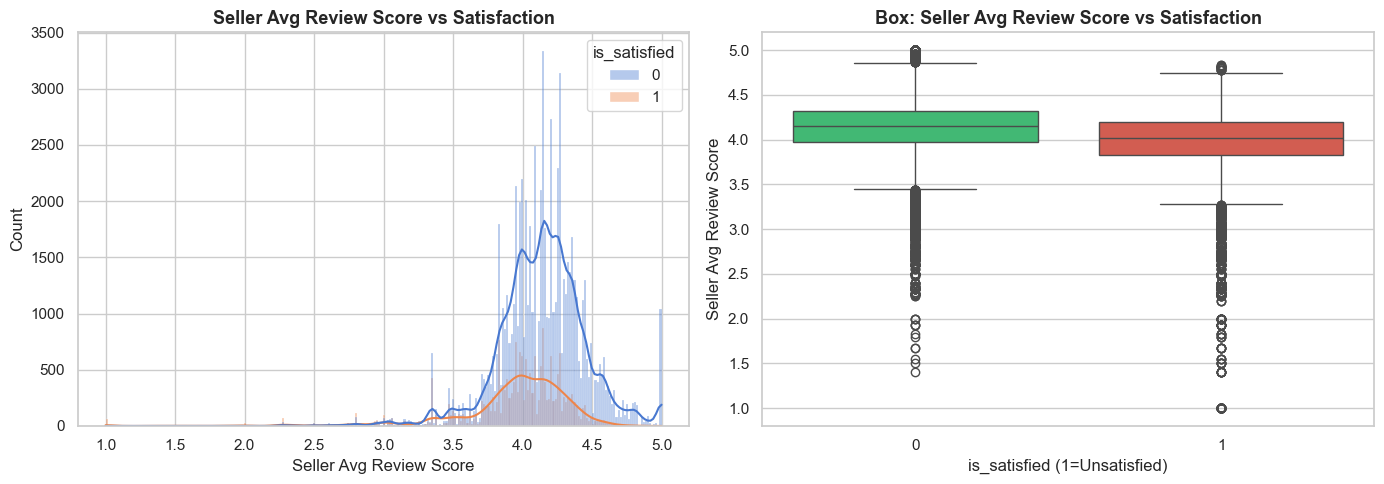

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=train_df, x='seller_avg_review_score', hue='is_satisfied', kde=True, alpha=0.4, ax=axes[0])
axes[0].set_title('Seller Avg Review Score vs Satisfaction', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Seller Avg Review Score')
axes[0].set_ylabel('Count')

sns.boxplot(data=train_df, x='is_satisfied', y='seller_avg_review_score',palette={'0':'#2ecc71', '1':'#e74c3c'}, ax=axes[1])
axes[1].set_title('Box: Seller Avg Review Score vs Satisfaction',fontweight='bold', fontsize=13)
axes[1].set_xlabel('is_satisfied (1=Unsatisfied)')
axes[1].set_ylabel('Seller Avg Review Score')

plt.tight_layout()
plt.show()

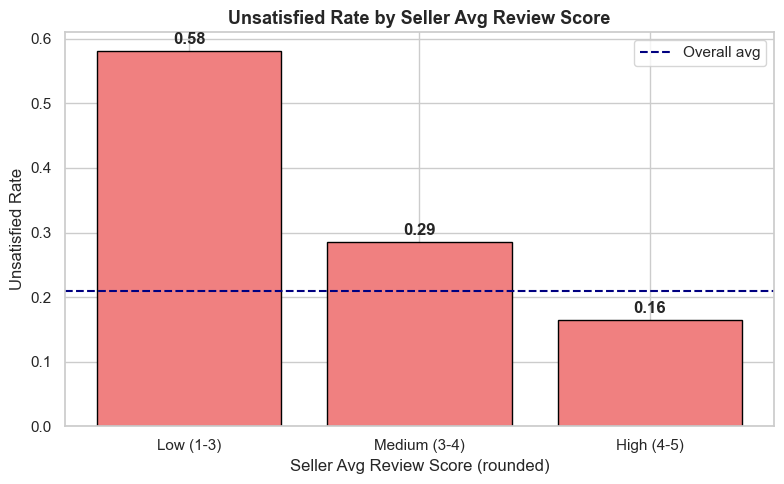

In [41]:
plt.figure(figsize=(8, 5))
bars = plt.bar(score_stats['review_score_bin'].astype(str), score_stats['unsat_rate'], color= 'lightcoral', edgecolor='black')
plt.bar_label(bars, fmt='%.2f', padding=3, fontweight='bold')
plt.axhline(train_df['is_satisfied'].mean(), color='navy', linestyle='--', label='Overall avg')
plt.title('Unsatisfied Rate by Seller Avg Review Score',fontweight='bold', fontsize=13)
plt.xlabel('Seller Avg Review Score (rounded)')
plt.ylabel('Unsatisfied Rate')
plt.legend()
plt.tight_layout()
plt.show()

- Seller average review score is the strongest feature in the EDA analysis, showing a clear inverse relationship with customer dissatisfaction (r = −0.277, small but strongest among features).
- Dissatisfaction decreases sharply across groups: Low (58.1%) → Medium (28.5%) → High (16.4%), with a very large gap of over 41 percentage points between the lowest and highest groups.
- This indicates that sellers with historically higher ratings consistently deliver better customer satisfaction outcomes, making this one of the most powerful predictive features in the dataset.

## 6.4 Seller Average Delay vs Satisfaction

In [42]:
# Mann-Whitney U Test — statistical test for seller_avg_delay vs satisfaction
mann_whitney_test(train_df, 'seller_avg_delay', target='is_satisfied', label='seller_avg_delay')
print('==' * 25)

# Bin seller average delay into 3 groups: Low, Medium, High
train_df['avg_delay_bin'] = pd.qcut(train_df['seller_avg_delay'], q=3, labels=['Low','Medium','High'], duplicates='drop')

# Group by average delay bins and calculate count and unsatisfied rate
delay_stats = (train_df.groupby('avg_delay_bin', observed=True)['is_satisfied'].agg(count='count', unsat_rate='mean').reset_index())
print("\nSeller Average Delay Bins:")
print(delay_stats)
print('==' * 25)

# Print seller average delay stats for each bin
print("\nSeller Average Delay by Satisfaction:")
print(train_df.groupby('avg_delay_bin', observed=True)['seller_avg_delay'].agg(['min','max','mean']).round(1))
print('==' * 25)


Mann-Whitney U Test — seller_avg_delay:
Statistic = 696,072,392 | p-value = 0.0000
Statistically significant difference (alpha = 0.05)
Effect size (r) = 0.0770 (negligible)

Seller Average Delay Bins:
  avg_delay_bin  count  unsat_rate
0           Low  32255    0.186421
1        Medium  31518    0.210737
2          High  31570    0.233513

Seller Average Delay by Satisfaction:
                min    max  mean
avg_delay_bin                   
Low           -66.0  -12.7 -15.2
Medium        -12.7  -10.9 -11.7
High          -10.9  167.0  -9.2


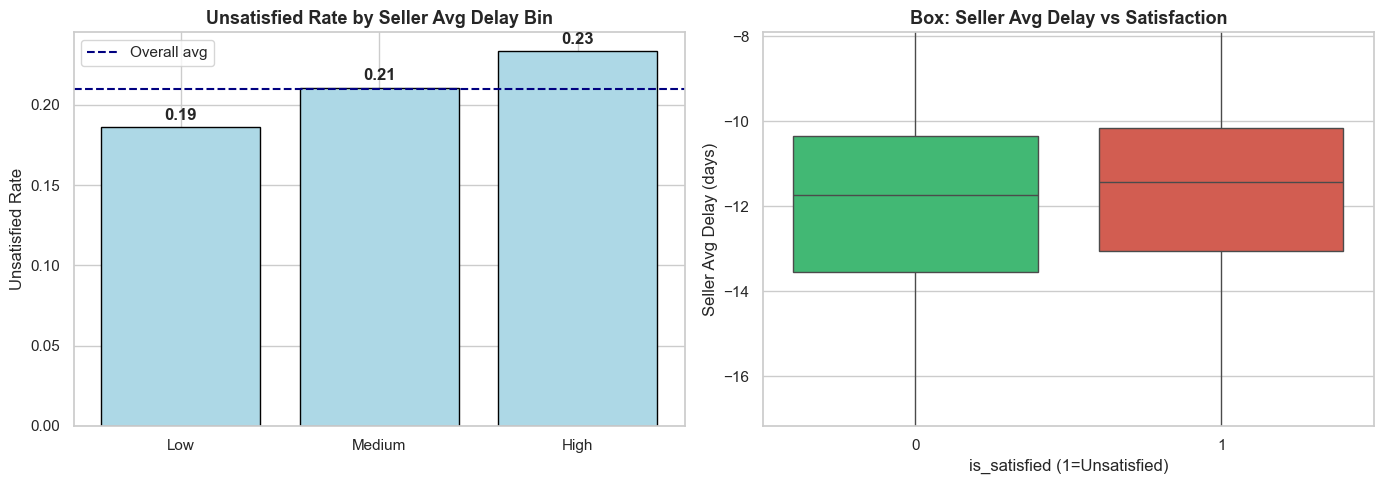

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Unsatisfied rate by seller average delay bins
bars = axes[0].bar(delay_stats['avg_delay_bin'].astype(str), delay_stats['unsat_rate'], color= 'lightblue', edgecolor='black')
axes[0].bar_label(bars, fmt='%.2f', padding=3, fontweight='bold')
axes[0].axhline(train_df['is_satisfied'].mean(), color='navy', linestyle='--', label='Overall avg')
axes[0].set_title('Unsatisfied Rate by Seller Avg Delay Bin', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Unsatisfied Rate'); axes[0].legend()

# Right: Boxplot of seller average delay vs satisfaction
sns.boxplot(data=train_df, x='is_satisfied', y='seller_avg_delay', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Box: Seller Avg Delay vs Satisfaction', fontweight='bold', fontsize=13)
axes[1].set_xlabel('is_satisfied (1=Unsatisfied)')
axes[1].set_ylabel('Seller Avg Delay (days)')
axes[1].set_ylim(train_df['seller_avg_delay'].quantile(0.05), train_df['seller_avg_delay'].quantile(0.95))

plt.tight_layout()
plt.show()

- Seller average delay has a weak relationship with customer dissatisfaction, despite being statistically significant (r = 0.077, negligible).
- Dissatisfaction increases slightly across groups: Low (18.6%) → Medium (21.1%) → High (23.4%), with a modest gap of about 4.7 percentage points.
- Compared to seller_late_rate, this feature is less discriminative, likely because average delay values are influenced by early deliveries, reducing its ability to clearly separate good and bad sellers.

# 7.Temporal Patterns 

## 7.1 Satisfaction by Day of Week, Month & Quarter

In [44]:
df = train_df.copy()

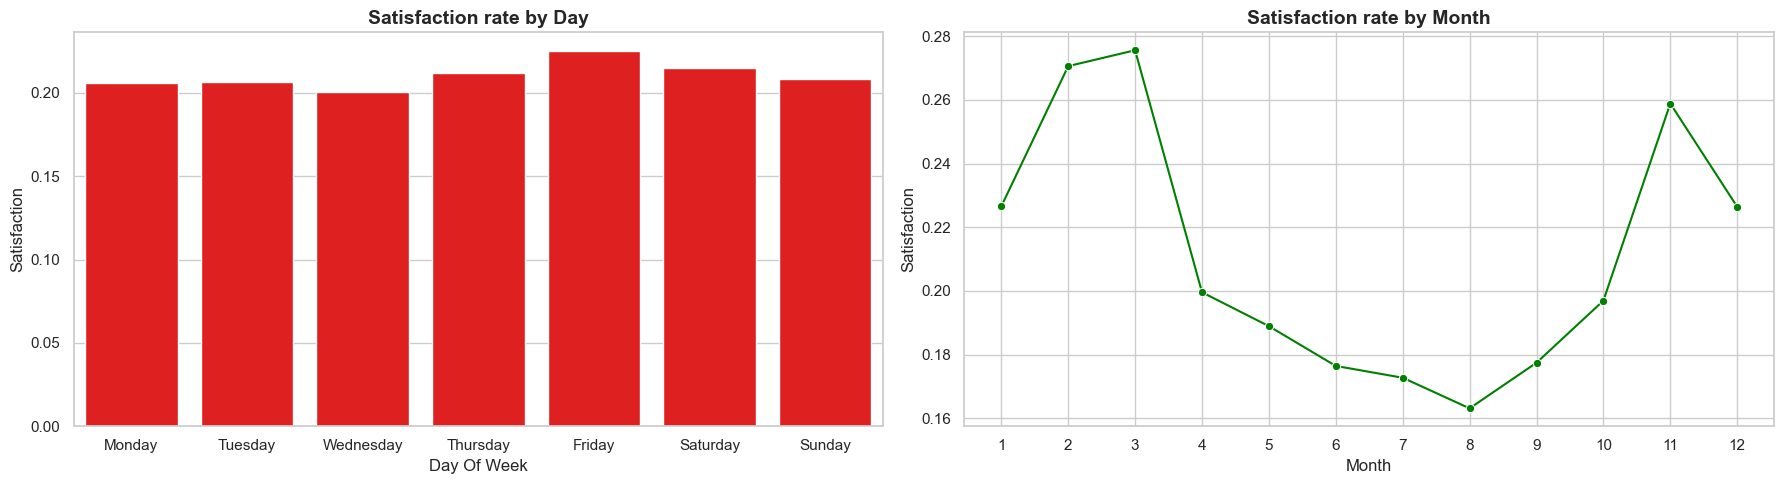

In [45]:
fig, axes = plt.subplots(1, 2, figsize = (18,5))
days_of_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Left Plot
sns.barplot(data = train_df, x = 'day_name', y = 'is_satisfied', order = days_of_week, ax = axes[0], color = 'red', errorbar= None)
axes[0].set_title('Satisfaction rate by Day', fontweight = 'bold', fontsize = 14)
axes[0].set_xlabel('Day Of Week')
axes[0].set_ylabel('Satisfaction')

# Right Plot
sns.lineplot(data = train_df, x = 'month', y = 'is_satisfied', ax = axes[1], color = 'green', marker = 'o', errorbar= None)
axes[1].set_xticks(range(1,13))
axes[1].set_title('Satisfaction rate by Month', fontweight = 'bold', fontsize = 14)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Satisfaction')

plt.tight_layout()
plt.show()

In [46]:
df.groupby('day_name')['is_satisfied'].agg(['count', 'mean']).reindex(days_of_week)

,count,mean
day_name,,
Monday,15502,0.205715
Tuesday,15344,0.206270
Wednesday,14884,0.200820
Thursday,14170,0.212068
Friday,13531,0.225113
Saturday,10406,0.214972
Sunday,11506,0.208239


In [47]:
df.groupby('month')['is_satisfied'].agg(['count', 'mean']).reset_index()

,month,count,mean
0,1,7703,0.226535
1,2,8071,0.270598
2,3,9427,0.275591
3,4,9020,0.199557
4,5,10206,0.188908
5,6,9149,0.176413
6,7,9907,0.172706
7,8,10448,0.163093
8,9,4092,0.177419
9,10,4682,0.196924


# 8. Feature Selection — Correlation Analysis & Multicollinearity Check

In [48]:
df = df.drop(['review_score'], axis = 1)

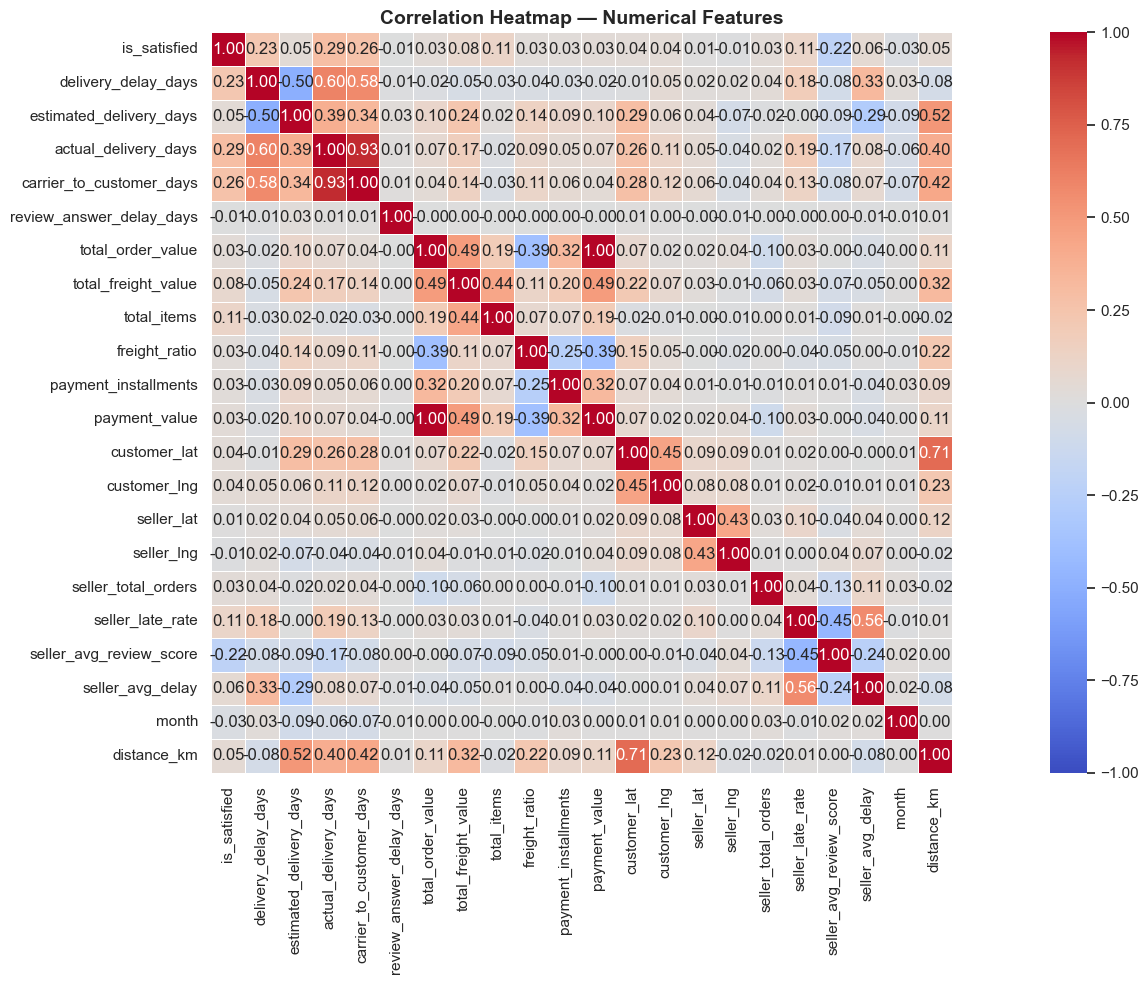

In [49]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = train_df[num_cols].corr()

plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, 
            annot=True, fmt='.2f', 
            cmap='coolwarm', center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

Correlation analysis identified redundant features causing multicollinearity:
- payment_value vs total_order_value (|r| = 1.0): perfectly redundant representations of the same quantity → total_order_value was removed.
quarter vs month (r = 0.97): quarter is derived from month → quarter was removed to avoid duplication.
- distance_km vs same_state (r = −0.57): moderately strong relationship; same_state was removed while distance_km was kept due to richer continuous information.
- Overall, removing these redundant features reduces multicollinearity, improves model stability, and slightly reduces input dimensionality without losing meaningful information.